In [1]:
from auxiliary_functions import *
from scipy.stats import gaussian_kde

In [2]:
graph = nx.read_gexf("graph.gexf")
print(type(graph))
std_threshold = 0.5
NumberOfRandoms = 300

<class 'networkx.classes.digraph.DiGraph'>


In [3]:
graph = simplify_graph(graph, std_threshold)

null_models = [generate_null_model(graph) for _ in range(NumberOfRandoms)]

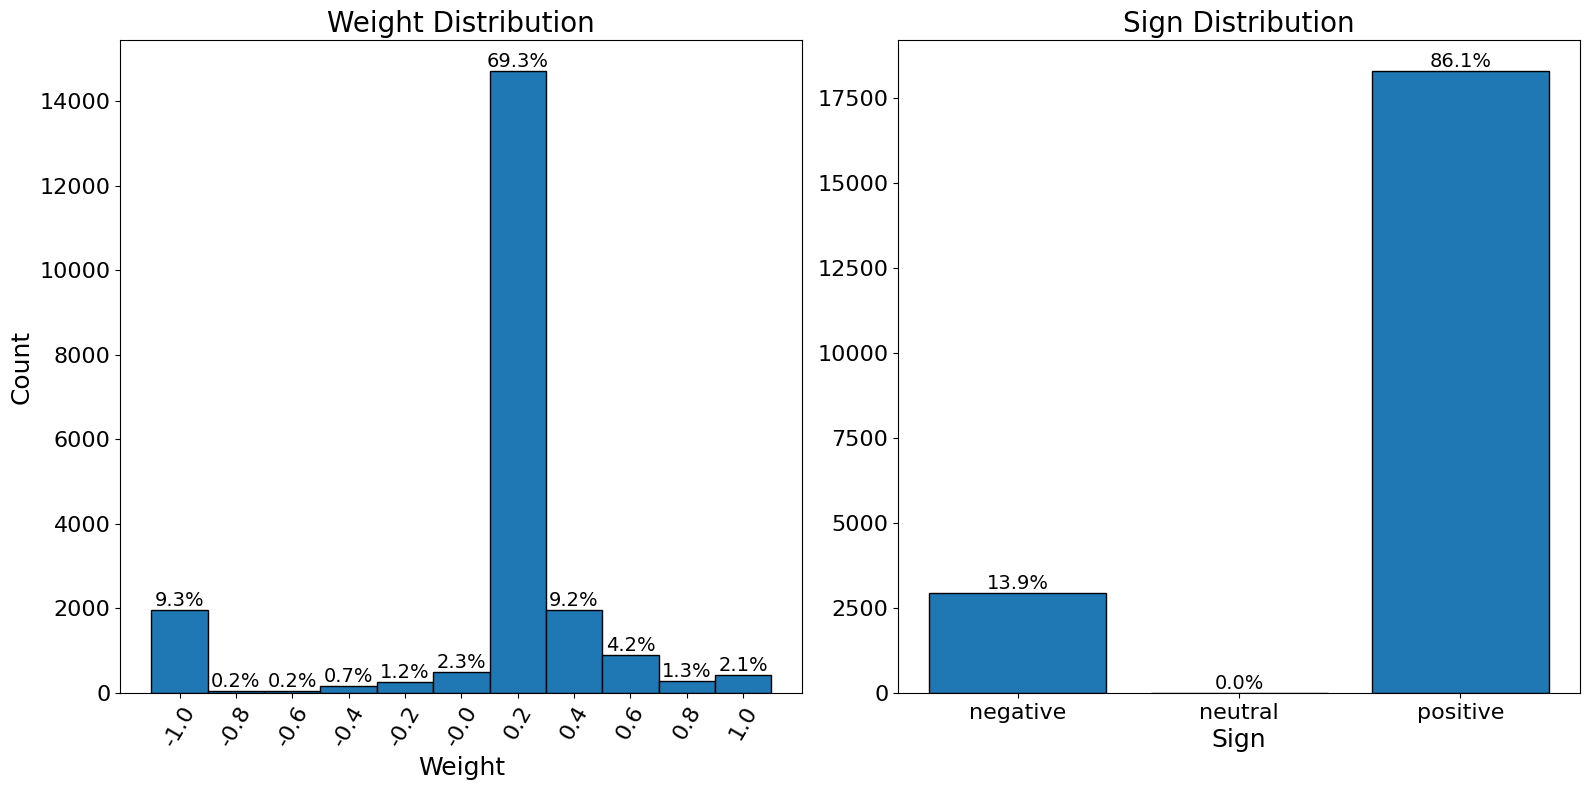

In [4]:
plot_weight_distribution(graph)

In [5]:
triangles_graph = calculate_triangles_graph(graph)

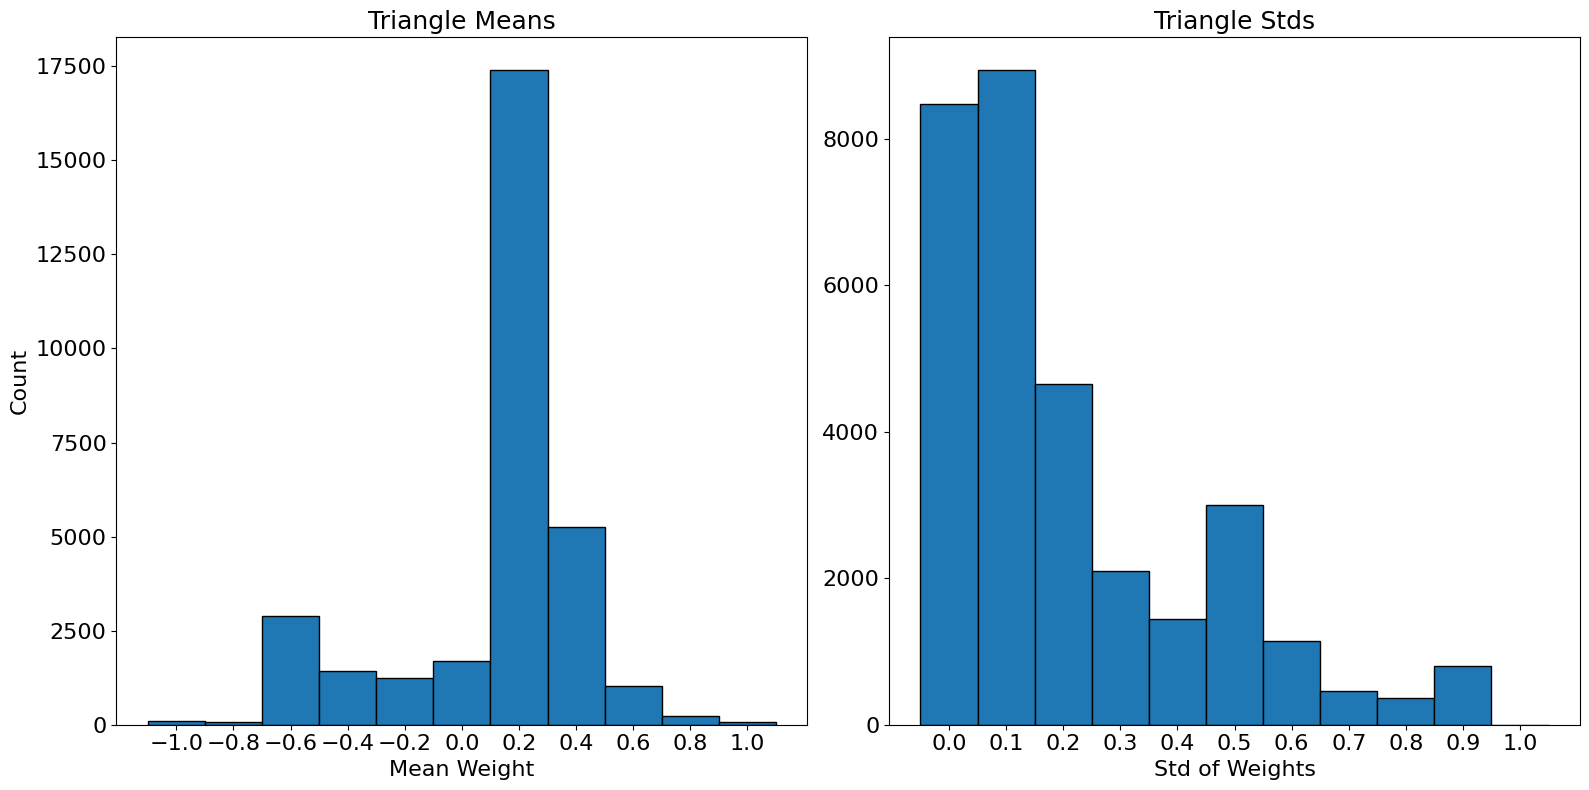

In [6]:
plot_triangle_distribution(triangles_graph)

In [7]:
df = number_of_triangles_per_type(triangles_graph)

#df.to_csv('file.csv', index=True)

df

,0 pos edges,1 pos edge,2 pos edges,3 pos edges
0,233,4938,3017,23203


In [8]:
null_triangles = calculate_triangles_null_graph(null_models)

In [9]:
results_nb, distributions_nb = non_binary_metric(triangles_graph, null_triangles)
results_nb

,prod,mean,std,z-score,percentile
0,0.040264,0.000007,0.000285,141.486681,100.0


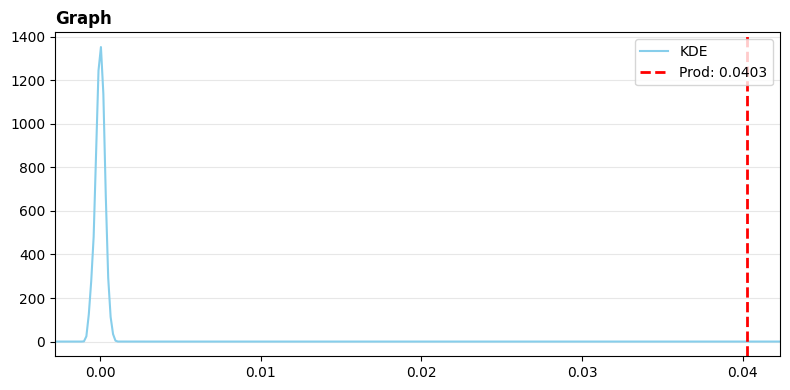

In [10]:
# Adapted for the single-graph case (but still supports a dict of one entry)
# If distributions_nb is array-like, treat it as a single distribution.
if isinstance(distributions_nb, dict):
    items = list(distributions_nb.items())
else:
    items = [("Graph", np.asarray(distributions_nb))]

num_subs = len(items)
fig, axes = plt.subplots(num_subs, 1, figsize=(8, 4 * num_subs))

if num_subs == 1:
    axes = [axes]

def _extract_prod(results, key=None):
    try:
        if key is not None:
            # try DataFrame/Series lookup by index/key
            try:
                return float(results.loc[key, "prod"])
            except Exception:
                pass
            try:
                return float(results[key])
            except Exception:
                pass
        # DataFrame/Series with 'prod' column
        try:
            return float(results["prod"].iloc[0])
        except Exception:
            pass
        # dict-like fallback
        if isinstance(results, dict) and "prod" in results:
            return float(results["prod"])
        # scalar fallback
        return float(results)
    except Exception:
        return None

for i, (name, distribution) in enumerate(items):
    ax = axes[i]
    distribution = np.asarray(distribution)
    if distribution.size == 0:
        ax.text(0.5, 0.5, "Empty distribution", ha="center")
        continue

    prod_val = _extract_prod(results_nb, key=name if isinstance(distributions_nb, dict) else None)
    # KDE with automatic x-range based on data
    kde = gaussian_kde(distribution)
    x_min, x_max = distribution.min(), max(distribution.max(), prod_val)
    pad = max(0.05 * (x_max - x_min), 1e-6)
    x_vals = np.linspace(x_min - pad, x_max + pad, 300)
    y_vals = kde(x_vals)
    ax.plot(x_vals, y_vals, color="skyblue", label="KDE")

    if prod_val is not None:
        ax.axvline(prod_val, color="red", linestyle="--", linewidth=2, label=f"Prod: {prod_val:.4f}")

    ax.set_title(f"Subreddit: r/{name}" if name != "Graph" else "Graph", loc="left", fontweight="bold")
    ax.set_xlim(x_vals.min(), x_vals.max())
    ax.legend(loc="upper right")
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
results_b, distributions_b = calculate_balance_metrics(graph, null_models, NumberOfRandoms)
results_b

Calculated 1/300
Calculated 2/300
Calculated 3/300
Calculated 4/300
Calculated 5/300
Calculated 6/300
Calculated 7/300
Calculated 8/300
Calculated 9/300
Calculated 10/300
Calculated 11/300
Calculated 12/300
Calculated 13/300
Calculated 14/300
Calculated 15/300
Calculated 16/300
Calculated 17/300
Calculated 18/300
Calculated 19/300
Calculated 20/300
Calculated 21/300
Calculated 22/300
Calculated 23/300
Calculated 24/300
Calculated 25/300
Calculated 26/300
Calculated 27/300
Calculated 28/300
Calculated 29/300
Calculated 30/300
Calculated 31/300
Calculated 32/300
Calculated 33/300
Calculated 34/300
Calculated 35/300
Calculated 36/300
Calculated 37/300
Calculated 38/300
Calculated 39/300
Calculated 40/300
Calculated 41/300
Calculated 42/300
Calculated 43/300
Calculated 44/300
Calculated 45/300
Calculated 46/300
Calculated 47/300
Calculated 48/300
Calculated 49/300
Calculated 50/300
Calculated 51/300
Calculated 52/300
Calculated 53/300
Calculated 54/300
Calculated 55/300
Calculated 56/300
C

{'B_w': np.float64(0.0063561913427724395),
 'mean': np.float64(0.022409856464754796),
 'std': np.float64(0.0008559928616559682),
 'z-score': np.float64(-18.754438081324185),
 'percentile': np.float64(0.0)}

In [17]:
distributions_b

[array([0.02167134, 0.02197324, 0.0221172 , 0.02296336, 0.02161718,
        0.0217692 , 0.02269931, 0.02269055, 0.02255491, 0.02113319,
        0.02246258, 0.02260921, 0.02124927, 0.02291982, 0.02189468,
        0.02130463, 0.0224897 , 0.02270588, 0.02145625, 0.02219712,
        0.02350955, 0.02096219, 0.02318145, 0.02253894, 0.02304055,
        0.02242961, 0.02137368, 0.02275458, 0.02143441, 0.02135423,
        0.02204594, 0.02258317, 0.02141444, 0.02300341, 0.02241397,
        0.02339021, 0.02224091, 0.02250408, 0.02360678, 0.02205551,
        0.02203222, 0.02253262, 0.02367226, 0.02215153, 0.02141891,
        0.02310568, 0.02228447, 0.02277248, 0.02359178, 0.02154141,
        0.02078781, 0.02125516, 0.02289636, 0.02247324, 0.02281334,
        0.02228307, 0.02167297, 0.02277856, 0.02302429, 0.02186896,
        0.0223116 , 0.02128454, 0.02220709, 0.02246003, 0.02165088,
        0.02228192, 0.0225011 , 0.02182911, 0.02162469, 0.02250856,
        0.02185976, 0.02247294, 0.0240378 , 0.02

In [ ]:
import json

with open('distribution', 'r') as f:
    distributions_b = json.load(f)
    
    
# list_subreddits = ["politics", "worldnews", "politicaldiscussion", "ukpolitics", "conservative", "neoliberal", "politicalhumor", "canadapolitics", "neutralpolitics", "australianpolitics"]
# results_b = [0.006191, 0.021197, 0.012899, 0.016738, 0.008455, 0.017590, 0.008977, 0.011335, 0.001428, 0.014914]

results = []

#bw = results_b["B_w"]
bw = 0.0063561913427724395
mean = np.mean(distributions_b)
std = np.std(distributions_b)
z_score = (bw - mean) / std if std != 0 else 0
percentile = (np.sum(np.array(distributions_b) < bw) / len(distributions_b)) * 100

results = {
	'bw': bw,
	'mean': mean,
	'std': std,
	'z-score': z_score,
	'percentile': percentile
}

results

{'bw': np.float64(0.0063561913427724395),
 'mean': np.float64(0.022409856464754796),
 'std': np.float64(0.0008559928616559682),
 'z-score': np.float64(-18.754438081324185),
 'percentile': np.float64(0.0)}

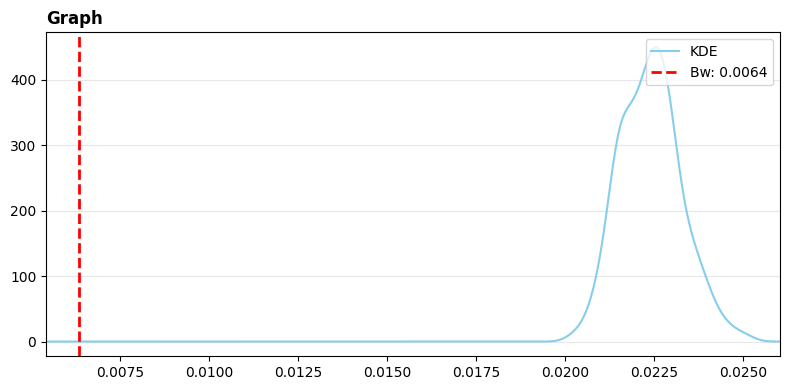

In [20]:
# Single-graph adaptation: treat distributions_b as a single distribution (or a dict with one entry)
if isinstance(distributions_b, dict):
    key = next(iter(distributions_b))
    distribution = np.asarray(distributions_b[key])
    title = f"Graph: {key}"
else:
    distribution = np.asarray(distributions_b)
    title = "Graph"

fig, ax = plt.subplots(figsize=(8, 4))

# Try to extract the single graph's Bw value from results_b
b_w = None
try:
    b_w = float(results_b["B_w"])
except Exception:
    try:
        b_w = float(results_b)  # scalar-like
    except Exception:
        try:
            b_w = float(results_b[0])  # sequence-like
        except Exception:
            b_w = None

if distribution.size == 0:
    ax.text(0.5, 0.5, "Empty distribution", ha='center')
else:
    # KDE with automatic x-range based on data
    kde = gaussian_kde(distribution)
    x_min, x_max = min(distribution.min(), b_w), max(distribution.max(), b_w)
    pad = max(0.05 * (x_max - x_min), 1e-6)
    x_vals = np.linspace(x_min - pad, x_max + pad, 300)
    y_vals = kde(x_vals)
    ax.plot(x_vals, y_vals, color='skyblue', label='KDE')


    if b_w is not None:
        ax.axvline(b_w, color='red', linestyle='--', linewidth=2, label=f'Bw: {b_w:.4f}')

ax.set_title(title, loc='left', fontweight='bold')
ax.set_xlim(x_vals.min() if distribution.size else -0.01, x_vals.max() if distribution.size else 0.06)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Single-graph adaptation: keep D_distribution as a dict with one key so downstream cells
# that expect .items() and results_df.loc[...] continue to work unchanged.

D_distribution = {"Graph": []}
results = []

# Handle triangles_graph being either a list of triangles (single graph) or a dict with one entry
if isinstance(triangles_graph, dict):
	key = next(iter(triangles_graph))
	real_triangles = triangles_graph[key]
else:
	real_triangles = triangles_graph

# Build frequency dict for real data
all_triangles_dict = defaultdict(int)
for triangle in real_triangles:
	val = geo_abs(triangle)
	all_triangles_dict[val] += 1
vals_all, cum_all = prepare_cumulative(all_triangles_dict)

# Handle null_triangles being either a list of null-model triangle lists or a dict with one entry
if isinstance(null_triangles, dict):
	null_models_list = null_triangles[next(iter(null_triangles))]
else:
	null_models_list = null_triangles

# Build frequency dicts for each null model
null_all_dicts = []
for null_model in null_models_list:
	null_all = defaultdict(int)
	for triangle in null_model:
		val = geo_abs(triangle)
		null_all[val] += 1
	null_all_dicts.append(null_all)

# Average null models to get reference cumulative
vals_all_null, cum_all_null = average_null_models(null_all_dicts)

# Compute distribution of D between each null model and the null average
for null_all in null_all_dicts:
	vals_null, cum_null = prepare_cumulative(null_all)
	D_null_vs_avg = kolmogorov(vals_null, cum_null, vals_all_null, cum_all_null)
	D_distribution["Graph"].append(D_null_vs_avg)

# Compute D for the real graph vs the null average
D = kolmogorov(vals_all, cum_all, vals_all_null, cum_all_null)

mean = np.mean(D_distribution["Graph"])
std = np.std(D_distribution["Graph"])
percentile = (np.sum(np.array(D_distribution["Graph"]) < D) / len(D_distribution["Graph"])) * 100

results.append({
	'D': D,
	"mean": mean,
	"std": std,
	"z-score": (D - mean) / std if std != 0 else 0,
	"percentile": percentile
})

results

[{'D': np.float64(8751.093333333334),
  'mean': np.float64(299.3273555555555),
  'std': np.float64(115.06603306237083),
  'z-score': np.float64(73.4514413406131),
  'percentile': np.float64(100.0)}]

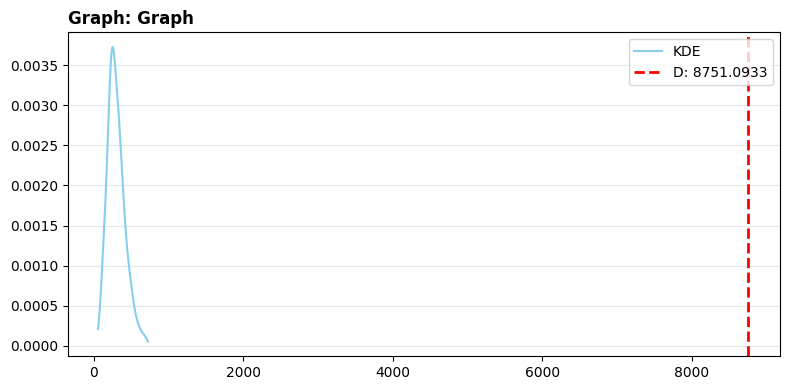

In [15]:
# Adaptation for single-graph (dimensions reduced by one).
# Use existing D_distribution and results_df (or fallback to D) without re-importing.

# Extract single distribution and a sensible title
if isinstance(D_distribution, dict):
	key = next(iter(D_distribution))
	distribution = np.asarray(D_distribution[key])
	title = f"Graph: {key}"
else:
	distribution = np.asarray(D_distribution)
	title = "Graph"

fig, ax = plt.subplots(figsize=(8, 4))

if distribution.size == 0:
	ax.text(0.5, 0.5, "Empty distribution", ha='center')
else:
	# Estimate KDE if there are enough points, otherwise show a rug/hist
	if distribution.size > 1:
		kde = gaussian_kde(distribution)
		x_min, x_max = distribution.min(), distribution.max()
		pad = max(0.05 * (x_max - x_min), 1e-6)
		x_vals = np.linspace(x_min - pad, x_max + pad, 300)
		y_vals = kde(x_vals)
		ax.plot(x_vals, y_vals, color='skyblue', label='KDE')
	else:
		# single point -> plot a vertical marker and small histogram fallback
		x_vals = np.array([distribution[0]])
		ax.plot(x_vals, np.array([1.0]), marker='o', linestyle='', color='skyblue', label='Value')

	# Robustly obtain the single graph D value (try results_df, then D variable)
	d_val = None
	try:
		# if results_df indexed by subreddit/key
		d_val = float(results_df.loc[key, 'D'])
	except Exception:
		try:
			d_val = float(results_df['D'].iloc[0])
		except Exception:
			try:
				d_val = float(D)  # fallback to D computed earlier
			except Exception:
				d_val = None

	if d_val is not None:
		ax.axvline(d_val, color='red', linestyle='--', linewidth=2, label=f'D: {d_val:.4f}')

	# Set x-limits based on data and optional D value
	data_min = distribution.min()
	data_max = distribution.max()
	if d_val is not None:
		data_min = min(data_min, d_val)
		data_max = max(data_max, d_val)
	pad = max(0.05 * (data_max - data_min if data_max != data_min else abs(data_max) + 1e-6), 1e-6)
	ax.set_xlim(data_min - pad, data_max + pad)

ax.set_title(title, loc='left', fontweight='bold')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [16]:
kolmogorov_smirnov(triangles_graph, null_triangles)

AttributeError: 'list' object has no attribute 'items'

Error in callback <function _draw_all_if_interactive at 0x7fbefdfc3380> (for post_execute), with arguments args (),kwargs {}:


ValueError: Image size of 1000x15695500 pixels is too large. It must be less than 2^23 in each direction.

ValueError: Image size of 1000x15695500 pixels is too large. It must be less than 2^23 in each direction.

<Figure size 1000x1.56955e+07 with 31391 Axes>